# Multi-Timeframe NY Session Breakout Strategy

This notebook implements a **Multi-Timeframe New York Session Breakout Strategy** for forex and commodities trading. The strategy combines daily candlestick pattern analysis with intraday (hourly) price action to identify and capitalize on breakout opportunities during the NY trading session.

## Strategy Overview

1. **Daily Signal Generation**: Analyzes daily candlestick patterns to determine bullish or bearish bias
2. **Intraday Execution**: Uses 2-hour candles to execute trades based on session breakouts
3. **Stop Price Calculation**: Determines entry levels based on initial session high/low
4. **Risk Management**: Implements automatic position closing at session end

---

## 1. Import Libraries and Define Helper Functions

In [1]:
import pandas as pd
import pandas_ta as ta
from tqdm import tqdm
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

tqdm.pandas()

def read_csv_to_dataframe(file_path):
    df = pd.read_csv(file_path)
    df["Gmt time"] = df["Gmt time"].str.replace(".000", "")
    df['Gmt time'] = pd.to_datetime(df['Gmt time'], format='%d.%m.%Y %H:%M:%S')
    df = df[df.High != df.Low]
    df.set_index("Gmt time", inplace=True)
    return df

def read_data_folder(folder_path="./data"):
    dataframes = []
    file_names = []
    for file_name in tqdm(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = read_csv_to_dataframe(file_path)
            dataframes.append(df)
            file_names.append(file_name)
    return dataframes, file_names

def daily_signal(df, current_candle):
    current_pos = df.index.get_loc(current_candle)
    c1 = df['Close'].iloc[current_pos] > df['Open'].iloc[current_pos]
    if c1:
        return 2
    
    c1 = df['Close'].iloc[current_pos] < df['Open'].iloc[current_pos]
    if c1:
        return 1

    return 0

def add_daily_signal(df):
    df['DailySignal'] = df.progress_apply(lambda row: daily_signal(df, row.name), axis=1).shift(1)
    return df

def add_pointpos_column(df, signal_column):
    """
    Adds a 'pointpos' column to the DataFrame to indicate the position of support and resistance points.
    
    Parameters:
    df (DataFrame): DataFrame containing the stock data with the specified SR column, 'Low', and 'High' columns.
    sr_column (str): The name of the column to consider for the SR (support/resistance) points.
    
    Returns:
    DataFrame: The original DataFrame with an additional 'pointpos' column.
    """
    def pointpos(row):
        if row[signal_column] == 2:
            return row['Low'] - 1e-4
        elif row[signal_column] == 1:
            return row['High'] + 1e-4
        else:
            return np.nan

    df['pointpos'] = df.apply(lambda row: pointpos(row), axis=1)
    return df

def plot_candlestick_with_signals(df, start_index, num_rows):
    """
    Plots a candlestick chart with signal points.
    
    Parameters:
    df (DataFrame): DataFrame containing the stock data with 'Open', 'High', 'Low', 'Close', and 'pointpos' columns.
    start_index (int): The starting index for the subset of data to plot.
    num_rows (int): The number of rows of data to plot.
    
    Returns:
    None
    """
    df_subset = df[start_index:start_index + num_rows]
    
    fig = make_subplots(rows=1, cols=1)
    
    fig.add_trace(go.Candlestick(x=df_subset.index,
                                 open=df_subset['Open'],
                                 high=df_subset['High'],
                                 low=df_subset['Low'],
                                 close=df_subset['Close'],
                                 name='Candlesticks'),
                  row=1, col=1)
    
    fig.add_trace(go.Scatter(x=df_subset.index, y=df_subset['pointpos'], mode="markers",
                             marker=dict(size=10, color="MediumPurple", symbol='circle'),
                             name="Entry Points"),
                  row=1, col=1)
    
    fig.update_layout(
        width=1200, 
        height=800, 
        plot_bgcolor='black',
        paper_bgcolor='black',
        font=dict(color='white'),
        xaxis=dict(showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False, zeroline=False),
        showlegend=True,
        legend=dict(
            x=0.01,
            y=0.99,
            traceorder="normal",
            font=dict(
                family="sans-serif",
                size=12,
                color="white"
            ),
            bgcolor="black",
            bordercolor="gray",
            borderwidth=2
        )
    )
    
    fig.show()

---

## 2. Load Data

Load the daily and hourly candlestick data from CSV files for multiple instruments (USDJPY, XAUUSD).

In [2]:
daily_df, daily_names = read_data_folder(folder_path="./data_daily")
hourly_df, hourly_names = read_data_folder(folder_path="./data_hourly")

100%|██████████| 3/3 [00:00<00:00, 11.48it/s]


In [4]:
hourly_names

['USDJPY_Candlestick_2_Hour_BID_01.06.2015-29.06.2024.csv',
 'XAUUSD_Candlestick_2_Hour_BID_01.06.2015-29.06.2024.csv']

---

## 3. Generate Daily Signals

Apply daily signal generation based on candlestick patterns:
- **Signal 2 (Bullish)**: Previous day closed higher than it opened
- **Signal 1 (Bearish)**: Previous day closed lower than it opened

In [3]:
for i, df in enumerate(daily_df):
    print("working on dataframe ", i, "...")
    df = add_daily_signal(df)
    df = add_pointpos_column(df, "DailySignal")
    daily_df[i] = df  # Update the dataframe in the list

working on dataframe  0 ...


100%|██████████| 2839/2839 [00:00<00:00, 47442.45it/s]


working on dataframe  1 ...


100%|██████████| 2821/2821 [00:00<00:00, 38747.88it/s]


In [4]:
sum([frame["DailySignal"].value_counts() for frame in daily_df], start=0)

DailySignal
2.0    3042
1.0    2611
0.0       5
Name: count, dtype: int64

### Signal Distribution

View the distribution of bullish vs bearish signals across all instruments:

In [7]:
# import pytz
# est = pytz.timezone('America/New_York')
# for dfH in hourly_df:
#     # Ensure the index is localized to GMT
#     if dfH.index.tz is None:
#         dfH.index = dfH.index.tz_localize('GMT')   
#         # Convert GMT to EST
#         dfH.index = dfH.index.tz_convert(est)

def apply_transformation(daily_dfs, hourly_dfs):
    transformed_hourly_dfs = []
    # Ensure that the indices of the hourly dataframe are sorted
        
    for dfD, dfH in zip(daily_dfs, hourly_dfs):
        dfH = dfH.sort_index()      
        # Reindex the daily dataframe to match the hourly dataframe indices with forward fill method
        dfH['DailySignal'] = dfD['DailySignal'].reindex(dfH.index, method='ffill')
        # Append the transformed dataframe to the list
        transformed_hourly_dfs.append(dfH)
        
    return transformed_hourly_dfs

hourly_df = apply_transformation(daily_df, hourly_df)

---

## 4. Apply Multi-Timeframe Alignment

Transfer daily signals to the hourly timeframe using forward-fill reindexing. This ensures that each hourly candle inherits the appropriate daily bias signal.

In [5]:
plot_candlestick_with_signals(daily_df[0], start_index=0, num_rows=355)

### Visualize Daily Signals

Interactive candlestick chart showing entry signal points:

In [9]:
import numpy as np

# def apply_strategy_df(df, test_candles = 2):
#     df['Exit'] = np.nan
#     df['StopPrice'] = np.nan
    
#     # Group the dataframe by date (day)
#     grouped = df.groupby(df.index.date)
    
#     for date, group in grouped:

#         # Set Exit to 1 in the last row of each day
#         df.loc[group.index[-1], 'Exit'] = 1

#         if (group['DailySignal'] == 2).any():
#             highest_in_test_hours = group.iloc[:test_candles]['High'].max()
#             if len(group) > test_candles:  # Check if there are more rows beyond the first
#                 df.loc[group.iloc[test_candles:].index, 'StopPrice'] = highest_in_test_hours
        
#         if (group['DailySignal'] == 1).any():
#             lowest_in_test_hours = group.iloc[:test_candles]['Low'].min()
#             if len(group) > test_candles:  # Check if there are more rows beyond the first
#                 df.loc[group.iloc[test_candles:].index, 'StopPrice'] = lowest_in_test_hours
    
#     return df


def apply_strategy_df(df, test_candles=2, exit_delay=1):
    df['Exit'] = np.nan  # Initialize with NaN
    df['StopPrice'] = np.nan  # Initialize with NaN
    
    # Convert index to datetime if not already
    df.index = pd.to_datetime(df.index)
    
    # Group the dataframe by date (day)
    grouped = df.groupby(df.index.date)
    
    # List of all dates in the index to access future dates safely
    all_dates = list(grouped.groups.keys())

    for i, date in enumerate(all_dates):
        group = grouped.get_group(date)

        # Determine the date to set the exit signal
        exit_date_index = i + exit_delay
        if exit_date_index < len(all_dates):
            exit_date = all_dates[exit_date_index]
            exit_group = grouped.get_group(exit_date)
            df.loc[exit_group.index[-1], 'Exit'] = 1

        # Handle the High and Low prices for DailySignal of 2 and 1 respectively
        if (group['DailySignal'] == 2).any():
            highest_in_test_hours = group.iloc[:test_candles]['High'].max()
            if len(group) > test_candles:
                df.loc[group.iloc[test_candles:].index, 'StopPrice'] = highest_in_test_hours
        
        if (group['DailySignal'] == 1).any():
            lowest_in_test_hours = group.iloc[:test_candles]['Low'].min()
            if len(group) > test_candles:
                df.loc[group.iloc[test_candles:].index, 'StopPrice'] = lowest_in_test_hours
    
    return df


def apply_strategy_dataframes(hourly_df, test_candles=2, exit_delay=1):
    transformed_hourly_dfs = []
    
    for df in hourly_df:
        df = apply_strategy_df(df, test_candles, exit_delay)
        transformed_hourly_dfs.append(df)
    
    return transformed_hourly_dfs

hourly_df = apply_strategy_dataframes(hourly_df, 8, 4)

    

---

## 5. Apply Trading Strategy

Define the breakout strategy logic:

- **Test Candles**: Number of initial candles to determine session high/low (default: 8)
- **Exit Delay**: Days to wait before exiting position (default: 4)
- **Stop Price**: Entry trigger level based on session extremes

### Strategy Rules:
1. For **bullish bias (Signal 2)**: Set buy stop at the highest high of the first N candles
2. For **bearish bias (Signal 1)**: Set sell stop at the lowest low of the first N candles
3. Exit all positions at the end of the specified delay period

In [10]:
hourly_df[0]

,Open,High,Low,Close,Volume,DailySignal,Exit,StopPrice
Gmt time,,,,,,,,
2015-06-01 00:00:00,124.252,124.343,124.150,124.188,11111.2300,NaN,NaN,NaN
2015-06-01 02:00:00,124.187,124.191,124.090,124.109,6449.4900,NaN,NaN,NaN
2015-06-01 04:00:00,124.106,124.209,123.939,124.199,8212.4602,NaN,NaN,NaN
2015-06-01 06:00:00,124.198,124.237,124.004,124.163,13842.1304,NaN,NaN,NaN
2015-06-01 08:00:00,124.164,124.172,123.979,124.040,14078.0498,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2024-06-28 12:00:00,160.648,160.662,160.261,160.461,48964.1993,2.0,NaN,NaN
2024-06-28 14:00:00,160.461,160.963,160.383,160.882,64126.7187,2.0,NaN,NaN
2024-06-28 16:00:00,160.881,160.903,160.756,160.796,19223.2295,2.0,NaN,161.282


### Preview Processed Data

View the hourly dataframe with added strategy columns:

In [11]:
import pandas as pd
from backtesting import Strategy, Backtest

def SIGNAL():
    return df.DailySignal

class Strat_01(Strategy):
    mysize = 0.1  # Trade size

    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)

    def next(self):
        super().next()

        #end of each session/day close all orders and trades
        if self.data.Exit[-1] == 1:
            self.cancel_orders()
            self.close_trades()

        self.handle_signals()

    def close_trades(self):
        if self.data.Exit[-1] == 1:
            for trade in self.trades:
                trade.close()

    def cancel_orders(self):
        while self.orders:
            self.orders[0].cancel()

    def handle_signals(self):
        if self.signal1[-1] == 2 and self.data.StopPrice[-1] > 0 and not self.position and len(self.orders) == 0:
            self.buy(size=self.mysize, stop=self.data.StopPrice[-1])

        elif self.signal1[-1] == 1 and self.data.StopPrice[-1] > 0 and not self.position and len(self.orders) == 0:
            self.sell(size=self.mysize, stop=self.data.StopPrice[-1])

f:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



---

## 6. Backtesting with Backtesting.py

Define the strategy class using the `backtesting.py` library for historical performance analysis.

### Strategy Implementation:
- Uses stop orders for entry (breakout confirmation)
- Closes all trades and cancels pending orders at session end
- Configurable position sizing and margin

In [12]:
results = []

for df in hourly_df:
    bt = Backtest(df, Strat_01, cash=5000, margin=1/5, commission=0.000)
    stats =  bt.run()
    results.append(stats)

### Run Backtest on All Instruments

Execute the backtest for each instrument in the dataset:

In [13]:
agg_returns = sum([r["Return [%]"] for r in results])
num_trades = sum([r["# Trades"] for r in results])
max_drawdown = min([r["Max. Drawdown [%]"] for r in results])
avg_drawdown = sum([r["Avg. Drawdown [%]"] for r in results]) / len(results)

win_rate = sum([r["Win Rate [%]"] for r in results]) / len(results)
best_trade = max([r["Best Trade [%]"] for r in results])
worst_trade = min([r["Worst Trade [%]"] for r in results])
avg_trade = sum([r["Avg. Trade [%]"] for r in results]) / len(results)
#max_trade_duration = max([r["Max. Trade Duration"] for r in results])
#avg_trade_duration = sum([r["Avg. Trade Duration"] for r in results]) / len(results)

print(f"Aggregated Returns: {agg_returns:.2f}%")
print(f"Number of Trades: {num_trades}")
print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Average Drawdown: {avg_drawdown:.2f}%")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Best Trade: {best_trade:.2f}%")
print(f"Worst Trade: {worst_trade:.2f}%")
print(f"Average Trade: {avg_trade:.2f}%")
#print(f"Maximum Trade Duration: {max_trade_duration} days")
#print(f"Average Trade Duration: {avg_trade_duration:.2f} days")


Aggregated Returns: 29.56%
Number of Trades: 1710
Maximum Drawdown: -5.78%
Average Drawdown: -0.33%
Win Rate: 51.15%
Best Trade: 7.73%
Worst Trade: -3.53%
Average Trade: 0.04%


---

## 7. Performance Metrics

Aggregate and display key performance indicators across all instruments:

In [14]:
equity_curves = [stats['_equity_curve']['Equity'] for stats in results]
max_length = max(len(equity) for equity in equity_curves)

# Pad each equity curve with the last value to match the maximum length
padded_equity_curves = []
for equity in equity_curves:
    last_value = equity.iloc[-1]
    padding = [last_value] * (max_length - len(equity))
    padded_equity = equity.tolist() + padding
    padded_equity_curves.append(padded_equity)

equity_df = pd.DataFrame(padded_equity_curves).T

---

## 8. Equity Curve Visualization

Create equity curves for visual comparison of strategy performance across instruments:

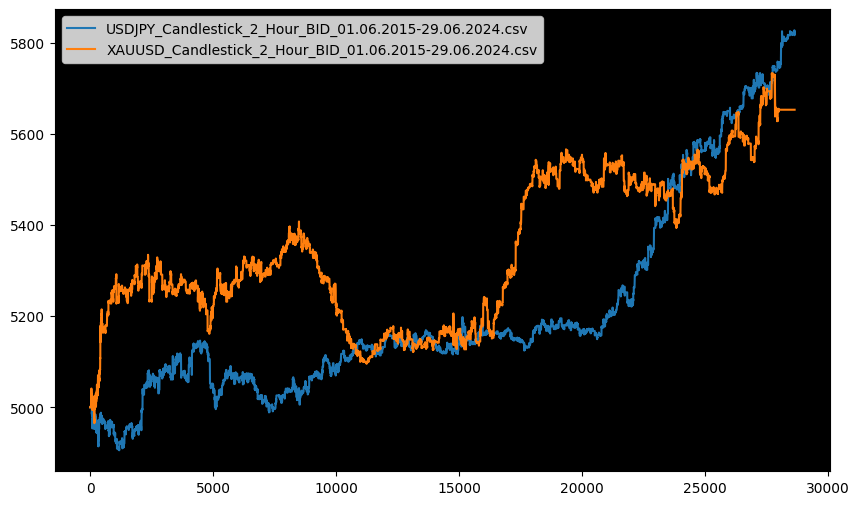

In [15]:
import matplotlib.pyplot as plt

equity_df.plot(kind='line', figsize=(10, 6), legend=True).set_facecolor('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().tick_params(axis='x', colors='black')
plt.gca().tick_params(axis='y', colors='black')
plt.gca().set_facecolor('black')
plt.legend(labels=hourly_names)

### Plot Equity Curves

Visualize the equity curves for all instruments:

In [16]:
[r["Return [%]"] for r in results]

[16.490820000000074, 13.073020000000069]

---

## 9. Individual Results Analysis

Examine returns and trades for each instrument:

In [17]:
hourly_names

['USDJPY_Candlestick_2_Hour_BID_01.06.2015-29.06.2024.csv',
 'XAUUSD_Candlestick_2_Hour_BID_01.06.2015-29.06.2024.csv']

In [20]:
results[0]["_trades"]

,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,PnL,ReturnPct,EntryTime,ExitTime,Duration
0,19,54,500,125.053,123.276,-33.763,-0.014210,2015-06-05 12:00:00,2015-07-28 00:00:00,52 days 12:00:00
1,20,524,536,123.947,124.076,2.580,0.001041,2015-07-30 00:00:00,2015-07-31 00:00:00,1 days 00:00:00
2,19,570,573,124.271,124.291,0.380,0.000161,2015-08-04 18:00:00,2015-08-05 00:00:00,0 days 06:00:00
3,19,603,608,124.962,124.151,-15.409,-0.006490,2015-08-07 12:00:00,2015-08-09 20:00:00,2 days 08:00:00
4,19,622,634,124.783,125.096,5.947,0.002508,2015-08-11 00:00:00,2015-08-12 00:00:00,1 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...
881,18,28529,28538,157.959,157.870,-1.602,-0.000563,2024-06-18 06:00:00,2024-06-19 00:00:00,0 days 18:00:00
882,18,28547,28550,157.950,157.955,0.090,0.000032,2024-06-19 18:00:00,2024-06-20 00:00:00,0 days 06:00:00
883,18,28559,28562,158.884,158.936,0.936,0.000327,2024-06-20 18:00:00,2024-06-21 00:00:00,0 days 06:00:00
884,18,28572,28573,159.628,159.751,2.214,0.000771,2024-06-21 20:00:00,2024-06-23 20:00:00,2 days 00:00:00


### Trade Log

View detailed trade history:

In [19]:
bt = Backtest(hourly_df[0], Strat_01, cash=5000, margin=1/5, commission=0.000)
stats =  bt.run()
#bt.plot()

ValueError: Indicators must return (optionally a tuple of) numpy.arrays of same length as `data` (data shape: (28634,); indicator "SIGNAL"shape: (28019,), returned value: [nan nan nan ...  2.  2.  2.])

---

## 10. Single Instrument Deep Dive

Run detailed backtest for a specific instrument:

In [70]:
hourly_df[0]

,Open,High,Low,Close,Volume,DailySignal,Exit,StopPrice
Gmt time,,,,,,,,
2015-06-01 00:00:00,124.252,124.343,124.150,124.188,11111.2300,NaN,NaN,NaN
2015-06-01 02:00:00,124.187,124.191,124.090,124.109,6449.4900,NaN,NaN,NaN
2015-06-01 04:00:00,124.106,124.209,123.939,124.199,8212.4602,NaN,NaN,NaN
2015-06-01 06:00:00,124.198,124.237,124.004,124.163,13842.1304,NaN,NaN,NaN
2015-06-01 08:00:00,124.164,124.172,123.979,124.040,14078.0498,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2024-06-28 12:00:00,160.648,160.662,160.261,160.461,48964.1993,2.0,NaN,NaN
2024-06-28 14:00:00,160.461,160.963,160.383,160.882,64126.7187,2.0,NaN,NaN
2024-06-28 16:00:00,160.881,160.903,160.756,160.796,19223.2295,2.0,NaN,161.282
